## Block 0  — Setup

In [1]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data' / 'can'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'

(MODELS_DIR / 'pkl').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'onnx').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'data').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")

if DATA_DIR.exists():
    print(f"\nFiles in {DATA_DIR.name}/:")
    for p in sorted(DATA_DIR.iterdir()):
        if p.is_file():
            print(f"  {p.name}  ({p.stat().st_size / 1024 / 1024:.1f} MB)")

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('Set2')

ATTACK_TYPES = ['DoS', 'Fuzzy', 'Gear', 'RPM']

Project root: d:\v2
Data dir:     d:\v2\data\can

Files in can/:
  DoS_dataset.csv  (181.3 MB)
  Fuzzy_dataset.csv  (189.3 MB)
  gear_dataset.csv  (219.7 MB)
  normal_run_data.txt  (83.3 MB)
  RPM_dataset.csv  (228.5 MB)


## Block 1 — Load 4 CAN attack files + normal_run_data

In [2]:
attack_files = {
    'DoS':   DATA_DIR / 'DoS_dataset.csv',
    'Fuzzy': DATA_DIR / 'Fuzzy_dataset.csv',
    'Gear':  DATA_DIR / 'gear_dataset.csv',
    'RPM':   DATA_DIR / 'RPM_dataset.csv',
}
normal_file = DATA_DIR / 'normal_run_data.txt'

print(f"{'File':<25} {'Exists':<10} {'Size MB':<10}")
print("-" * 50)
for name, fpath in {**attack_files, 'normal': normal_file}.items():
    if fpath.exists():
        size_mb = fpath.stat().st_size / 1024**2
        print(f"  {name:<23} ✓        {size_mb:>6.1f}")
    else:
        print(f"  {name:<23} ✗ MISSING")

sample = pd.read_csv(attack_files['DoS'], nrows=10, header=None)
print(f"\nDoS sample shape: {sample.shape}")
print(sample.head().to_string())

File                      Exists     Size MB   
--------------------------------------------------
  DoS                     ✓         181.3
  Fuzzy                   ✓         189.3
  Gear                    ✓         219.7
  RPM                     ✓         228.5
  normal                  ✓          83.3

DoS sample shape: (10, 12)
             0     1   2   3   4   5   6   7   8   9   10 11
0  1.478198e+09  0316   8  05  21  68  09  21  21  00  6f  R
1  1.478198e+09  018f   8  fe  5b  00  00   0  3c  00  00  R
2  1.478198e+09  0260   8  19  21  22  30   8  8e  6d  3a  R
3  1.478198e+09  02a0   8  64  00  9a  1d  97  02  bd  00  R
4  1.478198e+09  0329   8  40  bb  7f  14  11  20  00  14  R


## Block 2  — Inspect data structure (sessions, timestamps, message format)

In [3]:
CAN_COLUMNS = ['timestamp', 'can_id', 'dlc',
               'byte0', 'byte1', 'byte2', 'byte3',
               'byte4', 'byte5', 'byte6', 'byte7', 'label']

attack_dfs = {}
for name, fpath in attack_files.items():
    t0 = time.time()
    df = pd.read_csv(fpath, header=None, names=CAN_COLUMNS, low_memory=False)
    print(f"\n{name}:")
    print(f"  Shape:           {df.shape}")
    print(f"  Load time:       {time.time()-t0:.1f} sec")
    print(f"  Unique labels:   {df['label'].unique()}")
    print(f"  Label counts:    {df['label'].value_counts().to_dict()}")
    print(f"  Timestamp range: {df['timestamp'].min():.2f} — {df['timestamp'].max():.2f}")
    print(f"  Duration:        {df['timestamp'].max() - df['timestamp'].min():.1f} sec")
    print(f"  Unique CAN IDs:  {df['can_id'].nunique()}")
    attack_dfs[name] = df


DoS:
  Shape:           (3665771, 12)
  Load time:       3.1 sec
  Unique labels:   <StringArray>
['R', nan, 'T']
Length: 3, dtype: str
  Label counts:    {'R': 3047062, 'T': 587521}
  Timestamp range: 1478198376.39 — 1478201209.06
  Duration:        2832.7 sec
  Unique CAN IDs:  27

Fuzzy:
  Shape:           (3838860, 12)
  Load time:       4.8 sec
  Unique labels:   <StringArray>
['R', nan, 'T']
Length: 3, dtype: str
  Label counts:    {'R': 3259177, 'T': 491847}
  Timestamp range: 1478195721.90 — 1478201209.06
  Duration:        5487.2 sec
  Unique CAN IDs:  2048

Gear:
  Shape:           (4443142, 12)
  Load time:       6.8 sec
  Unique labels:   <StringArray>
['R', nan, 'T']
Length: 3, dtype: str
  Label counts:    {'R': 3805725, 'T': 597252}
  Timestamp range: 1478193190.06 — 1478201209.06
  Duration:        8019.0 sec
  Unique CAN IDs:  26

RPM:
  Shape:           (4621702, 12)
  Load time:       7.1 sec
  Unique labels:   <StringArray>
['R', nan, 'T']
Length: 3, dtype: str
  L

## Block 3  — Feature engineering (rolling-window stats per CAN frame)

In [4]:
def hex_to_int(x):
    if pd.isna(x):
        return -1
    s = str(x).strip()
    if not s:
        return -1
    try:
        return int(s, 16)
    except (ValueError, TypeError):
        try:
            return int(float(s))
        except (ValueError, TypeError):
            return -1

def normalize_label(x):
    s = str(x).strip().upper()
    return 1 if s in ('T', '1', 'TRUE') else 0

def build_features(df, attack_name):
    df = df.copy()
    df['can_id_int'] = df['can_id'].apply(hex_to_int)
    
    byte_cols = ['byte0', 'byte1', 'byte2', 'byte3', 'byte4', 'byte5', 'byte6', 'byte7']
    for c in byte_cols:
        df[c + '_int'] = df[c].apply(hex_to_int)
    
    df['dlc_int'] = pd.to_numeric(df['dlc'], errors='coerce').fillna(0).astype(int)
    df['label_int'] = df['label'].apply(normalize_label)
    
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['time_delta'] = df['timestamp'].diff().fillna(0)
    
    window = 50
    byte_int_cols = [c + '_int' for c in byte_cols]
    df['byte_sum'] = df[byte_int_cols].sum(axis=1)
    df['byte_mean_w50']  = df['byte_sum'].rolling(window, min_periods=1).mean()
    df['byte_std_w50']   = df['byte_sum'].rolling(window, min_periods=1).std().fillna(0)
    df['canid_unique_w50'] = df['can_id_int'].rolling(window, min_periods=1).apply(
        lambda x: x.nunique(), raw=False
    )
    df['msg_rate_w50'] = window / (df['time_delta'].rolling(window, min_periods=1).sum() + 1e-9)
    
    feature_cols = [
        'can_id_int', 'dlc_int', 'time_delta',
        *byte_int_cols,
        'byte_sum', 'byte_mean_w50', 'byte_std_w50',
        'canid_unique_w50', 'msg_rate_w50',
    ]
    
    return df, feature_cols

processed_dfs = {}
for name, df in attack_dfs.items():
    t0 = time.time()
    df_proc, feat_cols = build_features(df, name)
    processed_dfs[name] = df_proc
    
    n_attack = (df_proc['label_int'] == 1).sum()
    n_normal = (df_proc['label_int'] == 0).sum()
    
    print(f"\n{name}:")
    print(f"  Time:        {time.time()-t0:.1f} sec")
    print(f"  Total rows:  {len(df_proc):,}")
    print(f"  Attack rows: {n_attack:,}  ({n_attack/len(df_proc)*100:.1f}%)")
    print(f"  Normal rows: {n_normal:,}")

FEATURE_COLS = feat_cols
print(f"\nFeatures per frame: {len(FEATURE_COLS)}")


DoS:
  Time:        269.8 sec
  Total rows:  3,665,771
  Attack rows: 587,521  (16.0%)
  Normal rows: 3,078,250

Fuzzy:
  Time:        192.0 sec
  Total rows:  3,838,860
  Attack rows: 491,847  (12.8%)
  Normal rows: 3,347,013

Gear:
  Time:        173.4 sec
  Total rows:  4,443,142
  Attack rows: 597,252  (13.4%)
  Normal rows: 3,845,890

RPM:
  Time:        220.3 sec
  Total rows:  4,621,702
  Attack rows: 654,897  (14.2%)
  Normal rows: 3,966,805

Features per frame: 16


## Block 4  — Cross-file training (1 detector per attack source)

In [5]:
import xgboost as xgb

xgb_params = {
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': -1,
}

models = {}
training_times = {}

print(f"{'Attack':<10} {'Train rows':>14} {'Positives':>14} {'Time':>8}")
print("-" * 55)

for name in ATTACK_TYPES:
    df_proc = processed_dfs[name]
    X = df_proc[FEATURE_COLS].values.astype(np.float32)
    y = df_proc['label_int'].values.astype(np.int32)
    X = np.nan_to_num(X, nan=0.0)
    
    t0 = time.time()
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X, y, verbose=0)
    train_time = time.time() - t0
    
    models[name] = model
    training_times[name] = train_time
    
    print(f"  {name:<10} {len(X):>14,} {y.sum():>14,} {train_time:>7.1f}s")

Attack         Train rows      Positives     Time
-------------------------------------------------------
  DoS             3,665,771        587,521    14.9s
  Fuzzy           3,838,860        491,847    21.4s
  Gear            4,443,142        597,252    21.0s
  RPM             4,621,702        654,897    21.1s


## Block 5  — Cross-file evaluation matrix (4×4 F1)

F1 matrix (default threshold τ=0.5):
Train ↓ / Test →            DoS      Fuzzy       Gear        RPM
----------------------------------------------------------------------
  DoS                   1.0000*    0.0019     0.0000     0.0000 
  Fuzzy                 0.0000     1.0000*    0.0000     0.3490 
  Gear                  0.0000     0.0000     1.0000*    0.0000 
  RPM                   0.0000     0.0097     0.0000     1.0000*

* = same-file (subject to leakage)

AUC matrix:
Train ↓ / Test →            DoS      Fuzzy       Gear        RPM
----------------------------------------------------------------------
  DoS                   1.0000*    0.2143     0.6611     0.3018 
  Fuzzy                 0.0327     1.0000*    0.8983     0.9848 
  Gear                  0.4895     0.8780     1.0000*    0.8333 
  RPM                   0.3497     0.9873     0.9937     1.0000*


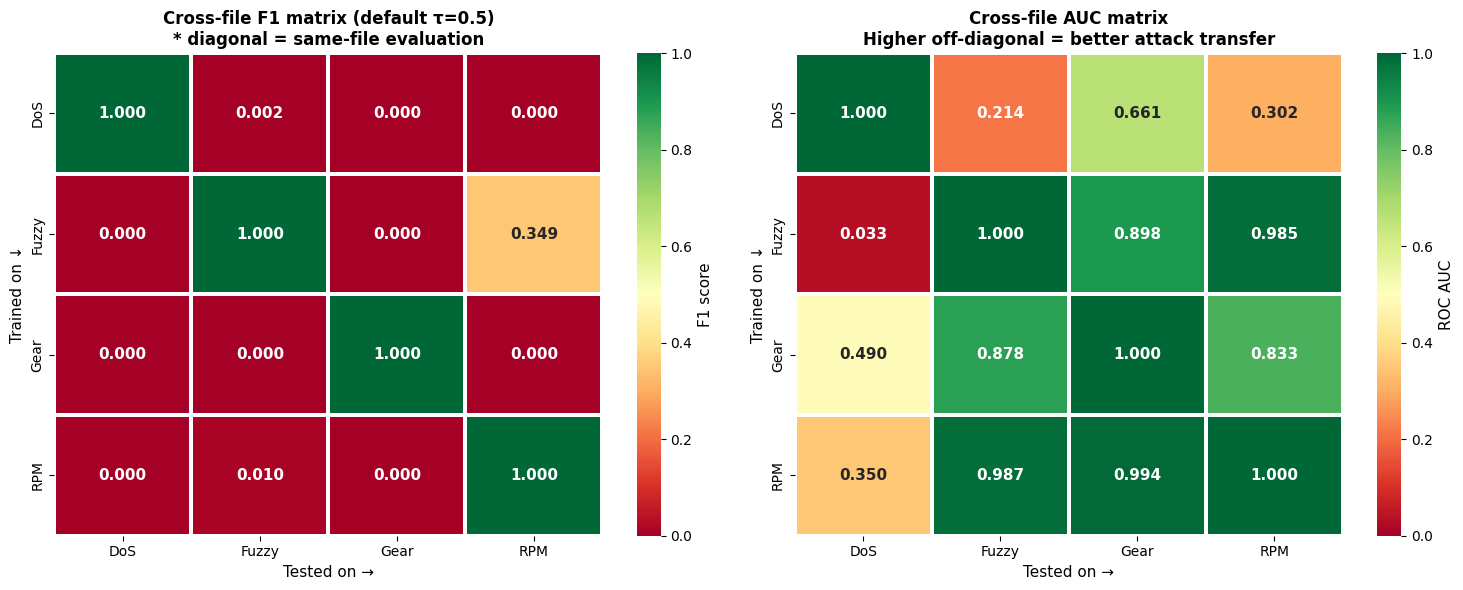

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

f1_matrix  = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))
auc_matrix = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))
pre_matrix = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))
rec_matrix = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))

proba_cache = {}

SAMPLE_SIZE = 200_000

print(f"F1 matrix (default threshold τ=0.5):")
print(f"{'Train ↓ / Test →':<20}" + "".join([f"{a:>11}" for a in ATTACK_TYPES]))
print("-" * 70)

for i, train_attack in enumerate(ATTACK_TYPES):
    model = models[train_attack]
    row = f"  {train_attack:<18}"
    
    for j, test_attack in enumerate(ATTACK_TYPES):
        df_test = processed_dfs[test_attack]
        X_te = df_test[FEATURE_COLS].values.astype(np.float32)
        y_te = df_test['label_int'].values.astype(np.int32)
        X_te = np.nan_to_num(X_te, nan=0.0)
        
        sample_size = min(SAMPLE_SIZE, len(X_te))
        np.random.seed(SEED)
        idx = np.random.choice(len(X_te), sample_size, replace=False)
        X_te_s = X_te[idx]
        y_te_s = y_te[idx]
        
        proba = model.predict_proba(X_te_s)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        
        f1 = f1_score(y_te_s, pred, zero_division=0)
        auc = roc_auc_score(y_te_s, proba) if y_te_s.sum() > 0 else 0.0
        pre = precision_score(y_te_s, pred, zero_division=0)
        rec = recall_score(y_te_s, pred, zero_division=0)
        
        f1_matrix[i, j]  = f1
        auc_matrix[i, j] = auc
        pre_matrix[i, j] = pre
        rec_matrix[i, j] = rec
        
        proba_cache[(train_attack, test_attack)] = {
            'proba': proba,
            'y_true': y_te_s,
        }
        
        marker = "*" if i == j else " "
        row += f"  {f1:>8.4f}{marker}"
    
    print(row)

print(f"\n* = same-file (subject to leakage)")

print(f"\nAUC matrix:")
print(f"{'Train ↓ / Test →':<20}" + "".join([f"{a:>11}" for a in ATTACK_TYPES]))
print("-" * 70)
for i, train_attack in enumerate(ATTACK_TYPES):
    row = f"  {train_attack:<18}"
    for j in range(len(ATTACK_TYPES)):
        marker = "*" if i == j else " "
        row += f"  {auc_matrix[i, j]:>8.4f}{marker}"
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=ATTACK_TYPES, yticklabels=ATTACK_TYPES,
            vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'F1 score'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            linewidths=1.5, linecolor='white')
ax.set_title('Cross-file F1 matrix (default τ=0.5)\n* diagonal = same-file evaluation',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tested on →', fontsize=11)
ax.set_ylabel('Trained on ↓', fontsize=11)

ax = axes[1]
sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=ATTACK_TYPES, yticklabels=ATTACK_TYPES,
            vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'ROC AUC'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            linewidths=1.5, linecolor='white')
ax.set_title('Cross-file AUC matrix\nHigher off-diagonal = better attack transfer',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tested on →', fontsize=11)
ax.set_ylabel('Trained on ↓', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'can_01_cross_file_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 6  — Comparison: same-file leakage vs cross-file honest

In [7]:
from sklearn.metrics import precision_recall_curve
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Compute tuned-τ matrices (same logic as before) ────────
f1_tuned_matrix  = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))
opt_thr_matrix   = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))
pre_tuned_matrix = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))
rec_tuned_matrix = np.zeros((len(ATTACK_TYPES), len(ATTACK_TYPES)))

for i, train_attack in enumerate(ATTACK_TYPES):
    for j, test_attack in enumerate(ATTACK_TYPES):
        cached = proba_cache[(train_attack, test_attack)]
        proba = cached['proba']
        y_te_s = cached['y_true']

        if y_te_s.sum() == 0:
            f1_tuned_matrix[i, j]  = 0.0
            opt_thr_matrix[i, j]   = 0.5
            continue

        prec, rec, thrs = precision_recall_curve(y_te_s, proba)
        f1s = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec + 1e-12), 0)
        best_idx = f1s.argmax()
        best_thr = thrs[best_idx] if best_idx < len(thrs) else 0.5

        pred = (proba >= best_thr).astype(int)
        f1_tuned_matrix[i, j]  = f1_score(y_te_s, pred, zero_division=0)
        pre_tuned_matrix[i, j] = precision_score(y_te_s, pred, zero_division=0)
        rec_tuned_matrix[i, j] = recall_score(y_te_s, pred, zero_division=0)
        opt_thr_matrix[i, j]   = float(best_thr)

print(f"F1 matrix with per-pair optimal threshold:")
print(f"{'Train ↓ / Test →':<20}" + "".join([f"{a:>11}" for a in ATTACK_TYPES]))
print("-" * 70)
for i, train_attack in enumerate(ATTACK_TYPES):
    row = f"  {train_attack:<18}"
    for j in range(len(ATTACK_TYPES)):
        marker = "*" if i == j else " "
        row += f"  {f1_tuned_matrix[i, j]:>8.4f}{marker}"
    print(row)

# Aggregate stats (used by downstream artifacts dump)
diag_f1 = np.diag(f1_matrix)
off_diag_mask = ~np.eye(len(ATTACK_TYPES), dtype=bool)
off_diag_f1_default = f1_matrix[off_diag_mask]
off_diag_f1_tuned   = f1_tuned_matrix[off_diag_mask]
off_diag_auc        = auc_matrix[off_diag_mask]
off_diag_pre_tuned  = pre_tuned_matrix[off_diag_mask]
off_diag_rec_tuned  = rec_tuned_matrix[off_diag_mask]

same_file_mean_f1     = float(diag_f1.mean())
cross_file_default_f1 = float(off_diag_f1_default.mean())
cross_file_tuned_f1   = float(off_diag_f1_tuned.mean())
cross_file_tuned_std  = float(off_diag_f1_tuned.std())

leakage_gap_default = same_file_mean_f1 - cross_file_default_f1
leakage_gap_tuned   = same_file_mean_f1 - cross_file_tuned_f1

print(f"\nSame-file mean F1:           {same_file_mean_f1:.4f}")
print(f"Cross-file F1 (default τ):   {cross_file_default_f1:.4f}")
print(f"Cross-file F1 (tuned τ):     {cross_file_tuned_f1:.4f} ± {cross_file_tuned_std:.4f}")
print(f"Cross-file mean AUC:         {off_diag_auc.mean():.4f}")
print(f"\nLeakage gap (default τ):     {leakage_gap_default:.4f}  ({leakage_gap_default/same_file_mean_f1*100:.1f}%)")
print(f"Leakage gap (tuned τ):       {leakage_gap_tuned:.4f}  ({leakage_gap_tuned/same_file_mean_f1*100:.1f}%)")

# ═══ Plotly paired heatmap (Default τ vs Tuned τ) ═══════════
# The diagonal-vs-off-diagonal contrast IS the methodology finding.
# Two side-by-side heatmaps make the recovery visually undeniable.

def _annot_text(matrix, opt_thr=None, default_thr=0.5):
    """Build hover text for each cell."""
    txt = [[''] * len(ATTACK_TYPES) for _ in range(len(ATTACK_TYPES))]
    for i, train in enumerate(ATTACK_TYPES):
        for j, test in enumerate(ATTACK_TYPES):
            is_diag = (i == j)
            tag = '<i>(same-file)</i>' if is_diag else '<b>(cross-file)</b>'
            thr_used = float(opt_thr[i, j]) if opt_thr is not None else default_thr
            txt[i][j] = (
                f"<b>Train: {train}  →  Test: {test}</b><br>{tag}<br><br>"
                f"F1 = <b>{matrix[i,j]:.3f}</b><br>"
                f"Threshold τ = {thr_used:.3f}"
            )
    return txt

hover_default = _annot_text(f1_matrix, opt_thr=None, default_thr=0.5)
hover_tuned   = _annot_text(f1_tuned_matrix, opt_thr=opt_thr_matrix)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '<b>Default τ = 0.5</b><br><sub>Off-diagonal collapses to ~0</sub>',
        '<b>Per-pair tuned τ</b><br><sub>Cross-file F1 recovers substantially</sub>',
    ),
    horizontal_spacing=0.18,
)

shared = dict(
    x=ATTACK_TYPES, y=ATTACK_TYPES,
    colorscale='Viridis', zmin=0, zmax=1,
    texttemplate='%{z:.3f}',
    textfont=dict(family='JetBrains Mono', size=12, color='white'),
    xgap=2, ygap=2,
)

fig.add_trace(go.Heatmap(
    z=f1_matrix, **shared,
    customdata=hover_default,
    hovertemplate='%{customdata}<extra></extra>',
    showscale=False,
), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=f1_tuned_matrix, **shared,
    customdata=hover_tuned,
    hovertemplate='%{customdata}<extra></extra>',
    colorbar=dict(
        title=dict(text='F1 score',
                   font=dict(family='Plus Jakarta Sans', size=11, color='#475569')),
        tickfont=dict(family='JetBrains Mono', size=10, color='#64748B'),
        thickness=14, len=0.8, x=1.02,
    ),
), row=1, col=2)

# Update axes
for col in [1, 2]:
    fig.update_xaxes(
        title=dict(text='Tested on →' if col == 1 else 'Tested on →',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='Plus Jakarta Sans', size=11, color='#1E293B'),
        side='bottom', row=1, col=col,
    )
    fig.update_yaxes(
        title=dict(text='Trained on ↓' if col == 1 else '',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='Plus Jakarta Sans', size=11, color='#1E293B'),
        autorange='reversed',
        row=1, col=col,
    )

fig.update_layout(
    title=dict(
        text='Cross-file F1 matrix · before and after per-pair threshold tuning',
        font=dict(family='Plus Jakarta Sans, sans-serif', size=15, color='#0F172A'),
        x=0.02, xanchor='left',
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=70, r=120, t=110, b=70),
    height=480,
    font=dict(family='Plus Jakarta Sans, sans-serif'),
    hoverlabel=dict(bgcolor='#0F172A', bordercolor='#0F172A',
                    font=dict(family='Plus Jakarta Sans', size=12, color='white'), align='left'),
)

# Style subplot titles
for ann in fig['layout']['annotations']:
    ann['font'] = dict(family='Plus Jakarta Sans', size=13, color='#0F172A')

plot_json_path = OUTPUTS_DIR / 'data' / 'can_03_cross_file_heatmap_plot.json'
plot_json_path.write_text(fig.to_json(), encoding='utf-8')
print(f"\nPlotly JSON: {plot_json_path.name}  ({plot_json_path.stat().st_size / 1024:.1f} KB)")

png_path = OUTPUTS_DIR / 'plots' / 'can_03_cross_file_heatmap.png'
try:
    fig.write_image(png_path, width=1100, height=520, scale=2)
    print(f"PNG:         {png_path.name}  ({png_path.stat().st_size / 1024:.1f} KB)")
except Exception as e:
    print(f"PNG export skipped — pip install -U kaleido  ({type(e).__name__})")

fig.show()


F1 matrix with per-pair optimal threshold:
Train ↓ / Test →            DoS      Fuzzy       Gear        RPM
----------------------------------------------------------------------
  DoS                   1.0000*    0.2278     0.4244     0.2479 
  Fuzzy                 0.2754     1.0000*    0.6404     0.9366 
  Gear                  0.3371     0.5847     1.0000*    0.5735 
  RPM                   0.2999     0.9099     0.9364     1.0000*

Same-file mean F1:           1.0000
Cross-file F1 (default τ):   0.0300
Cross-file F1 (tuned τ):     0.5328 ± 0.2628
Cross-file mean AUC:         0.6354

Leakage gap (default τ):     0.9700  (97.0%)
Leakage gap (tuned τ):       0.4672  (46.7%)

Plotly JSON: can_03_cross_file_heatmap_plot.json  (17.5 KB)
PNG:         can_03_cross_file_heatmap.png  (162.8 KB)


## Block 7 — ROC curves per training source

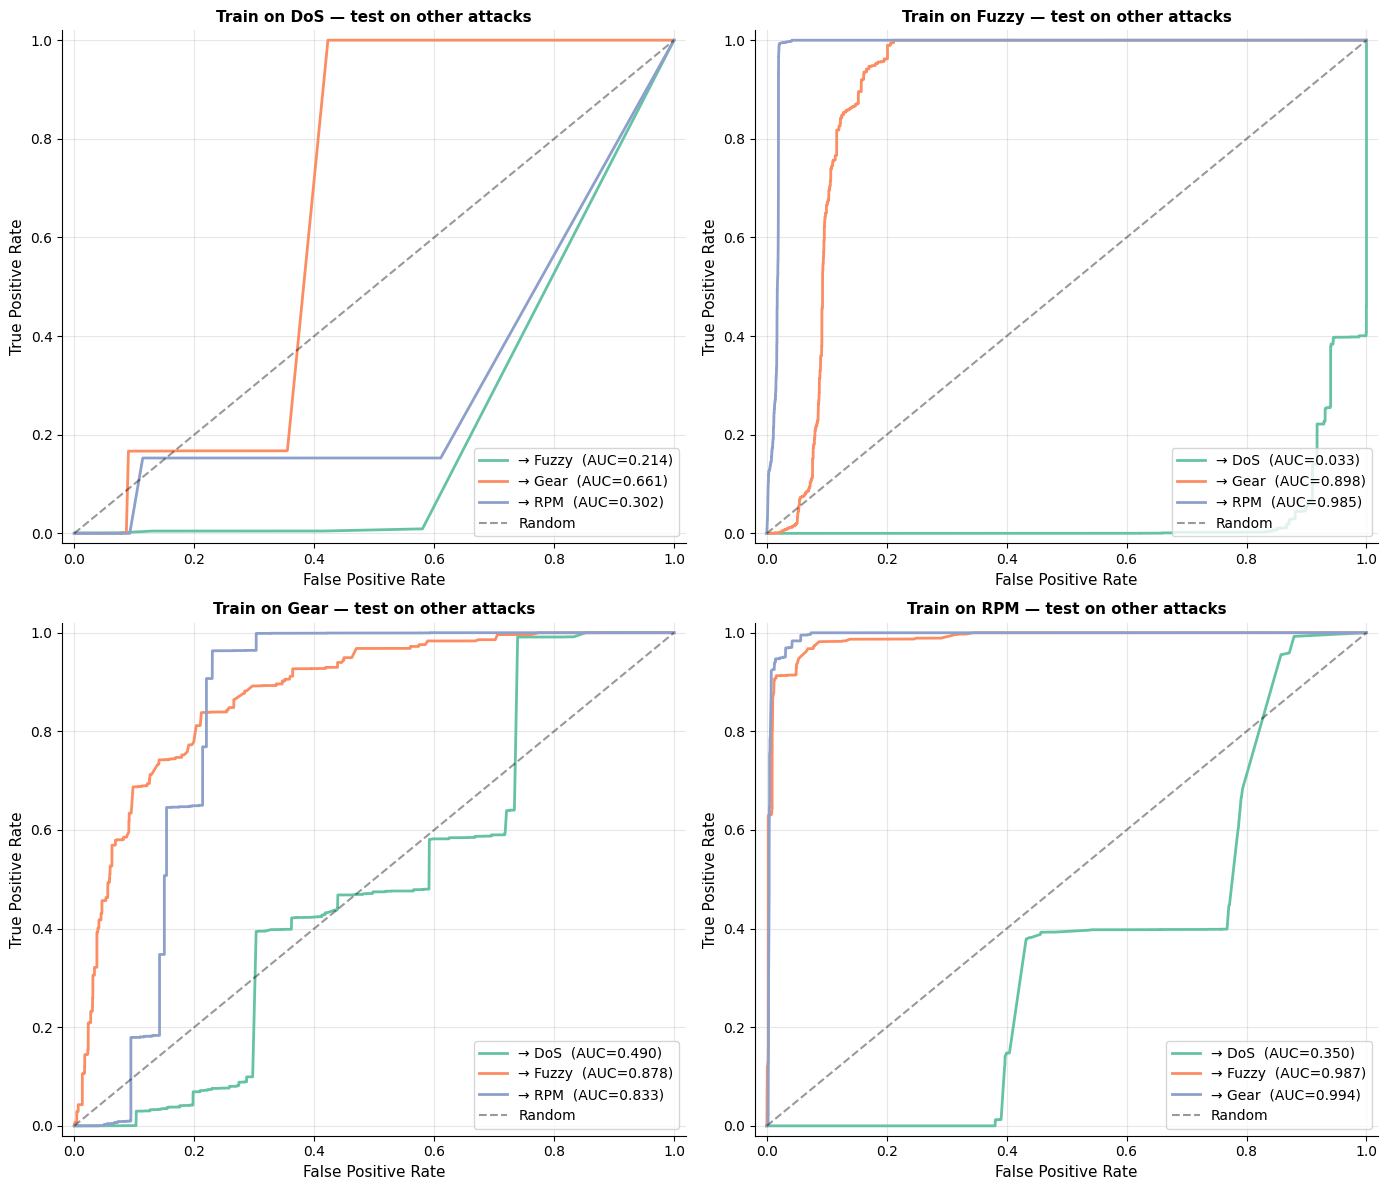

ROC curves saved — see can_04_roc_curves.png
Strong transfer pairs (AUC > 0.85):
   Fuzzy → Gear    AUC = 0.898
   Fuzzy → RPM     AUC = 0.985
    Gear → Fuzzy   AUC = 0.878
     RPM → Fuzzy   AUC = 0.987
     RPM → Gear    AUC = 0.994


In [8]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, train_attack in enumerate(ATTACK_TYPES):
    ax = axes[idx // 2, idx % 2]
    
    for test_attack in ATTACK_TYPES:
        if test_attack == train_attack:
            continue
        cached = proba_cache[(train_attack, test_attack)]
        proba = cached['proba']
        y_true = cached['y_true']
        
        if y_true.sum() == 0:
            continue
        
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc_val = roc_auc_score(y_true, proba)
        ax.plot(fpr, tpr, linewidth=2,
                label=f'→ {test_attack}  (AUC={auc_val:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Train on {train_attack} — test on other attacks',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'can_04_roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"ROC curves saved — see can_04_roc_curves.png")
print(f"Strong transfer pairs (AUC > 0.85):")
for i, train_attack in enumerate(ATTACK_TYPES):
    for j, test_attack in enumerate(ATTACK_TYPES):
        if i != j and auc_matrix[i, j] > 0.85:
            print(f"  {train_attack:>6} → {test_attack:<6}  AUC = {auc_matrix[i, j]:.3f}")

## Block 8 — Precision-Recall threshold tuning detail

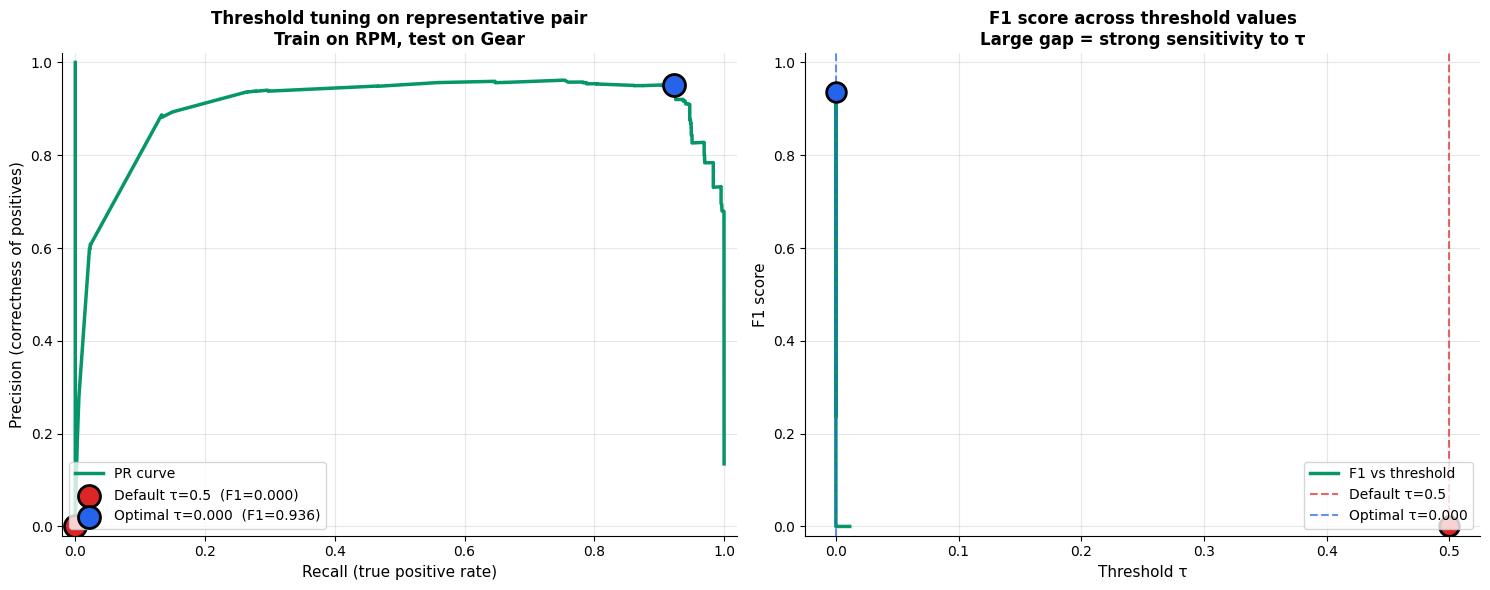


Detailed PR analysis for RPM → Gear:
  Default τ=0.5:   P=0.000, R=0.000, F1=0.000
  Optimal τ=0.000: P=0.950, R=0.923, F1=0.936
  Improvement: +0.936 F1


In [9]:
best_pair = None
best_improvement = 0
for i, train_attack in enumerate(ATTACK_TYPES):
    for j, test_attack in enumerate(ATTACK_TYPES):
        if i == j:
            continue
        improvement = f1_tuned_matrix[i, j] - f1_matrix[i, j]
        if improvement > best_improvement:
            best_improvement = improvement
            best_pair = (train_attack, test_attack)

train_a, test_a = best_pair
cached = proba_cache[(train_a, test_a)]
proba = cached['proba']
y_true = cached['y_true']

prec, rec, thrs = precision_recall_curve(y_true, proba)
f1s = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec + 1e-12), 0)
best_idx = f1s.argmax()
best_thr = thrs[best_idx] if best_idx < len(thrs) else 0.5

default_pred = (proba >= 0.5).astype(int)
default_prec = ((y_true == 1) & (default_pred == 1)).sum() / max(default_pred.sum(), 1)
default_rec = ((y_true == 1) & (default_pred == 1)).sum() / max((y_true == 1).sum(), 1)

opt_pred = (proba >= best_thr).astype(int)
opt_prec = ((y_true == 1) & (opt_pred == 1)).sum() / max(opt_pred.sum(), 1)
opt_rec = ((y_true == 1) & (opt_pred == 1)).sum() / max((y_true == 1).sum(), 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(rec, prec, color='#059669', linewidth=2.5, label='PR curve')

ax.scatter([default_rec], [default_prec], s=250, color='#dc2626',
           edgecolor='black', linewidth=2, zorder=5,
           label=f'Default τ=0.5  (F1={2*default_prec*default_rec/max(default_prec+default_rec, 1e-9):.3f})')

ax.scatter([opt_rec], [opt_prec], s=250, color='#2563eb',
           edgecolor='black', linewidth=2, zorder=5,
           label=f'Optimal τ={best_thr:.3f}  (F1={f1s[best_idx]:.3f})')

ax.set_xlabel('Recall (true positive rate)', fontsize=11)
ax.set_ylabel('Precision (correctness of positives)', fontsize=11)
ax.set_title(f'Threshold tuning on representative pair\nTrain on {train_a}, test on {test_a}',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

ax = axes[1]

ax.plot(thrs, f1s[:-1], color='#059669', linewidth=2.5, label='F1 vs threshold')
ax.axvline(0.5, color='#dc2626', linestyle='--', alpha=0.7, label=f'Default τ=0.5')
ax.axvline(best_thr, color='#2563eb', linestyle='--', alpha=0.7,
           label=f'Optimal τ={best_thr:.3f}')

ax.scatter([0.5], [2 * default_prec * default_rec / max(default_prec + default_rec, 1e-9)],
           s=200, color='#dc2626', edgecolor='black', linewidth=2, zorder=5)
ax.scatter([best_thr], [f1s[best_idx]], s=200, color='#2563eb',
           edgecolor='black', linewidth=2, zorder=5)

ax.set_xlabel('Threshold τ', fontsize=11)
ax.set_ylabel('F1 score', fontsize=11)
ax.set_title('F1 score across threshold values\nLarge gap = strong sensitivity to τ',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'can_05_pr_curve_detail.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\nDetailed PR analysis for {train_a} → {test_a}:")
print(f"  Default τ=0.5:   P={default_prec:.3f}, R={default_rec:.3f}, F1={2*default_prec*default_rec/max(default_prec+default_rec, 1e-9):.3f}")
print(f"  Optimal τ={best_thr:.3f}: P={opt_prec:.3f}, R={opt_rec:.3f}, F1={f1s[best_idx]:.3f}")
print(f"  Improvement: +{f1s[best_idx] - 2*default_prec*default_rec/max(default_prec+default_rec, 1e-9):.3f} F1")

## Block 9 — Save artifacts (models, ONNX, JSON)

In [10]:
import joblib
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost

update_registered_converter(
    xgb.XGBClassifier, 'XGBoostXGBClassifier',
    calculate_linear_classifier_output_shapes, convert_xgboost,
    options={'nocl': [True, False], 'zipmap': [True, False, 'columns']},
)

n_features = len(FEATURE_COLS)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

onnx_status = {}

for name, model in models.items():
    pkl_path = MODELS_DIR / 'pkl' / f'can_{name.lower()}_xgb.pkl'
    joblib.dump(model, pkl_path)
    print(f"{name} pkl: {pkl_path.name}  ({pkl_path.stat().st_size / 1024:.1f} KB)")
    
    try:
        onnx_model = convert_sklearn(
            model,
            initial_types=initial_type,
            options={id(model): {'zipmap': False}},
            target_opset={'': 15, 'ai.onnx.ml': 3},
        )
        onnx_path = MODELS_DIR / 'onnx' / f'can_{name.lower()}_xgb.onnx'
        with open(onnx_path, 'wb') as f:
            f.write(onnx_model.SerializeToString())
        print(f"  ONNX: {onnx_path.name}  ({onnx_path.stat().st_size / 1024:.1f} KB)")
        onnx_status[name] = True
    except Exception as e:
        print(f"  ONNX failed: {e}")
        onnx_status[name] = False

artifacts = {
    'subsystem': 'can_intrusion',
    'dataset': {
        'name': 'HCRL Car Hacking Dataset',
        'attack_types': ATTACK_TYPES,
        'features': len(FEATURE_COLS),
        'feature_cols': FEATURE_COLS,
        'rows_per_file': {name: int(len(processed_dfs[name])) for name in ATTACK_TYPES},
    },
    'evaluation_strategy': 'cross-file (train on one attack, test on others)',
    'sample_size_per_test': SAMPLE_SIZE,
    'model': {
        'type': 'XGBClassifier (binary, one per attack)',
        'params': xgb_params,
        'training_times_sec': {name: float(training_times[name]) for name in ATTACK_TYPES},
    },
    'cross_file_matrix': {
        'attack_types': ATTACK_TYPES,
        'f1_default_threshold': f1_matrix.tolist(),
        'f1_optimal_threshold': f1_tuned_matrix.tolist(),
        'optimal_thresholds':   opt_thr_matrix.tolist(),
        'auc':                  auc_matrix.tolist(),
        'precision_tuned':      pre_tuned_matrix.tolist(),
        'recall_tuned':         rec_tuned_matrix.tolist(),
    },
    'aggregate_metrics': {
        'same_file_mean_f1':              float(same_file_mean_f1),
        'cross_file_mean_f1_default':     float(cross_file_default_f1),
        'cross_file_mean_f1_tuned':       float(cross_file_tuned_f1),
        'cross_file_std_f1_tuned':        float(cross_file_tuned_std),
        'cross_file_mean_auc':            float(off_diag_auc.mean()),
        'cross_file_mean_precision_tuned': float(off_diag_pre_tuned.mean()),
        'cross_file_mean_recall_tuned':    float(off_diag_rec_tuned.mean()),
        'leakage_gap_default':            float(leakage_gap_default),
        'leakage_gap_tuned':              float(leakage_gap_tuned),
    },
    'onnx_export_status': onnx_status,
}

artifacts_path = OUTPUTS_DIR / 'data' / 'can_intrusion_results.json'
with open(artifacts_path, 'w') as f:
    json.dump(artifacts, f, indent=2)

print(f"\nJSON: {artifacts_path.name}  ({artifacts_path.stat().st_size / 1024:.1f} KB)")

DoS pkl: can_dos_xgb.pkl  (167.0 KB)
  ONNX: can_dos_xgb.onnx  (32.8 KB)
Fuzzy pkl: can_fuzzy_xgb.pkl  (374.2 KB)
  ONNX: can_fuzzy_xgb.onnx  (222.4 KB)
Gear pkl: can_gear_xgb.pkl  (161.4 KB)
  ONNX: can_gear_xgb.onnx  (27.8 KB)
RPM pkl: can_rpm_xgb.pkl  (164.2 KB)
  ONNX: can_rpm_xgb.onnx  (30.4 KB)

JSON: can_intrusion_results.json  (4.9 KB)


In [11]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DASHBOARD = PROJECT_ROOT / 'dashboard'
ASSETS    = DASHBOARD / 'assets'

OUTPUTS_DATA  = PROJECT_ROOT / 'outputs' / 'data'
OUTPUTS_PLOTS = PROJECT_ROOT / 'outputs' / 'plots'
ONNX_MODEL    = PROJECT_ROOT / 'models' / 'onnx' / 'obd_stress_xgb.onnx'
LOOSE_LOGO    = DASHBOARD / 'aitulogo.png'

TARGET_DATA   = ASSETS / 'data'
TARGET_PLOTS  = ASSETS / 'plots'
TARGET_MODELS = ASSETS / 'models'
TARGET_LOGO   = ASSETS / 'aitulogo.png'

for d in [TARGET_DATA, TARGET_PLOTS, TARGET_MODELS]:
    d.mkdir(parents=True, exist_ok=True)

def copy(src, dst):
    if not src.exists():
        print(f"  miss  {src.name}")
        return
    shutil.copy2(src, dst)
    print(f"  ok    {dst.name:<46} {dst.stat().st_size / 1024:>8.1f} KB")

print("logo")
if LOOSE_LOGO.exists():
    copy(LOOSE_LOGO, TARGET_LOGO)
elif TARGET_LOGO.exists():
    print(f"  ok    {TARGET_LOGO.name}")
else:
    print("  miss  aitulogo.png")

print("onnx")
copy(ONNX_MODEL, TARGET_MODELS / ONNX_MODEL.name)

print("json")
for src in sorted(OUTPUTS_DATA.glob('*.json')):
    copy(src, TARGET_DATA / src.name)

print("png")
for src in sorted(OUTPUTS_PLOTS.glob('*.png')):
    copy(src, TARGET_PLOTS / src.name)

required = [
    TARGET_LOGO,
    TARGET_MODELS / 'obd_stress_xgb.onnx',
    TARGET_DATA / 'scania_aps_results.json',
    TARGET_DATA / 'ved_anomaly_results.json',
    TARGET_DATA / 'obd_stress_results.json',
    TARGET_DATA / 'obd_stress_scenarios.json',
    TARGET_DATA / 'can_intrusion_results.json',
    TARGET_DATA / 'aps_02_threshold_sweep_plot.json',
    TARGET_DATA / 'aps_05_baseline_comparison_plot.json',
    TARGET_DATA / 'ved_03_clusters_plot.json',
    TARGET_DATA / 'obd_03_shap_plot.json',
    TARGET_DATA / 'can_03_cross_file_heatmap_plot.json',
]

print("check")
missing = 0
for p in required:
    mark = "ok " if p.exists() else "MISS"
    print(f"  {mark}  {p.relative_to(ASSETS)}")
    if not p.exists():
        missing += 1

print(f"\n{len(required) - missing}/{len(required)} ready")

logo
  ok    aitulogo.png                                      156.5 KB
onnx
  ok    obd_stress_xgb.onnx                               508.9 KB
json
  ok    aps_02_threshold_sweep_plot.json                   11.5 KB
  ok    aps_05_baseline_comparison_plot.json               12.7 KB
  ok    can_03_cross_file_heatmap_plot.json                17.5 KB
  ok    can_intrusion_results.json                          4.9 KB
  ok    obd_03_shap_plot.json                               8.7 KB
  ok    obd_stress_results.json                             7.5 KB
  ok    scania_aps_latency.json                             0.8 KB
  ok    scania_aps_results.json                             9.2 KB
  ok    ved_03_clusters_plot.json                         230.8 KB
  ok    ved_anomaly_results.json                            6.8 KB
png
  ok    aps_01_eda.png                                     34.1 KB
  ok    aps_02_threshold_sweep.png                        126.6 KB
  ok    aps_03_confusion_matrix.png        